# Sunspot time series alignment

We have seen the official sunspot number time series, averaged by months, in sequence 1. We have seen an algorithm for automatic sunspot detection in sequence 2. Now we will compare the two for the period between the last two minima, from 2009 to 2020.

In [21]:
import pandas as pd
import requests
import os
import numpy as np
import datetime
import matplotlib.pyplot as plt

For the official sunspot number, we already have a local copy of the data, from sequence 1. We load it again, extract the period we are interested in, and plot the sunspot number.

In [22]:
data = pd.read_csv('sunspot.csv', delimiter=";", 
                   names= ["Year", "Month", "Year_Fraction", "SunspotNumber", "SunspotNumber_sd",
                           "NumObservations", "Definitive?"])

In [23]:
sunspot_numbers = data[(data.Year >= 2009) & (data.Year <= 2020)].copy()

In [24]:
sunspot_numbers[sunspot_numbers["SunspotNumber_sd"]==sunspot_numbers["SunspotNumber_sd"].max()]

,Year,Month,Year_Fraction,SunspotNumber,SunspotNumber_sd,NumObservations,Definitive?
3181,2014,2,2014.123,146.1,10.7,384,1


<Axes: xlabel='Year_Fraction'>

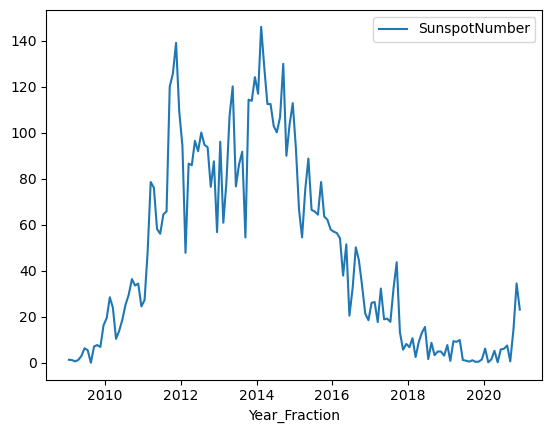

In [25]:
sunspot_numbers.plot(x='Year_Fraction', y='SunspotNumber')

To get a comparable time series for the sunspot counts from our algorithm, we have to run it on many input images and compute monthly averages. The workflow that we will be using as a running example in this MOOC does exactly that. For now, all we care about is the result file, which you can find at 
https://gitlab.inria.fr/sunspot-detection/sunspot-detection-with-snakemake/-/raw/main/results/sunspots/monthly_sunspot-numbers_2009-2020.txt. We download a local copy, just like we did for the sunspot number file.

In [26]:
if not os.path.exists('monthly_sunspot-numbers_2009-2020.txt'):
    url = 'https://gitlab.inria.fr/sunspot-detection/sunspot-detection-with-snakemake/-/raw/main/results/sunspots/monthly_sunspot-numbers_2009-2020.txt'
    r = requests.get(url, allow_redirects=True)
    open('monthly_sunspot-numbers_2009-2020.txt', 'wb').write(r.content)

Now we can read the file. The format is simple: each line contains a date in ISO format (the day always being the 15th), followed by white space and a number, which is the average sunspot count for the month indicated by the date. 

In [27]:
sunspot_counts = []
for line in open("monthly_sunspot-numbers_2009-2020.txt"):
    date_str, count_str = line.split()
    date = datetime.date.fromisoformat(date_str)
    count = float(count_str)
    sunspot_counts.append((date, count))
sunspot_counts = pd.DataFrame(sunspot_counts, columns=['Date', 'SunspotCount'])

In [28]:
sunspot_counts[sunspot_counts["SunspotCount"]==sunspot_counts["SunspotCount"].max()]

,Date,SunspotCount
59,2014-02-15,16.0


<Axes: xlabel='Date'>

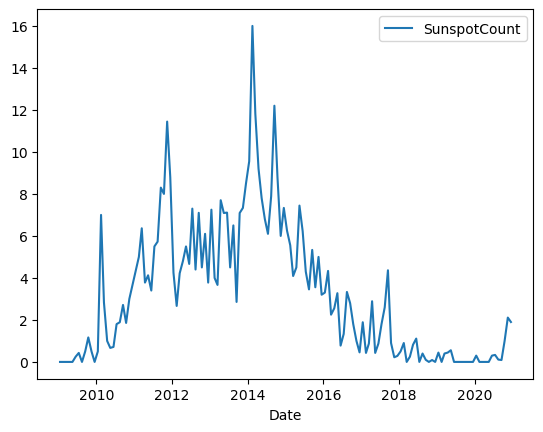

In [29]:
sunspot_counts.plot(x = 'Date', y = 'SunspotCount')

The two plots have the same overall shape, but not the same magnitude. This is in fact to be expected: our sunspot count is simply the number of sunspots detected by our algorithm, whereas the official sunspot number is computed as the number of sunspots plus 10 times the number of sunspot groups, both numbers being estimated by a trained expert (see [here](https://www.sidc.be/SILSO/infosndtot) for more explanations).

As a first attempt, we will see if a simple scale factor is sufficient to align the two time series.

In [30]:
sunspot_numbers["Date"] = sunspot_numbers.apply(lambda row: datetime.date(int(row["Year"]), int(row["Month"]), 15), axis=1)

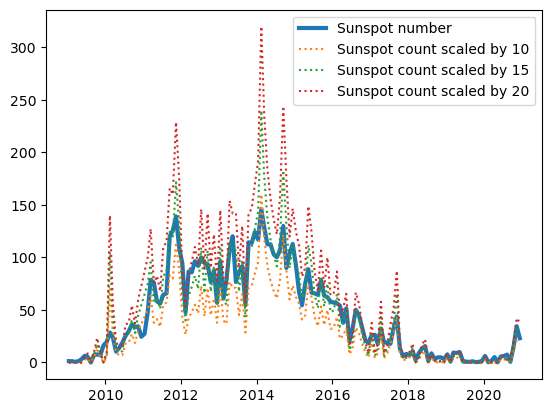

In [31]:
fig, ax = plt.subplots()

ax.plot_date(sunspot_numbers["Date"], sunspot_numbers["SunspotNumber"],
             '-', linewidth=3,
             label="Sunspot number")
for scale in [10, 15, 20]:
    ax.plot_date(sunspot_counts["Date"], scale*sunspot_counts["SunspotCount"],
                 ":",
                 label=f"Sunspot count scaled by {scale}")
plt.legend()
plt.show()

In [45]:
d = pd.merge(sunspot_numbers, sunspot_counts, on="Date")
d["result"] = d["SunspotNumber"] + 10*d["SunspotCount"]
d[d["result"] == d["result"].max()]



,Year,Month,Year_Fraction,SunspotNumber,SunspotNumber_sd,NumObservations,Definitive?,Date,SunspotCount,result
59,2014,2,2014.123,146.1,10.7,384,1,2014-02-15,16.0,306.1


A scale factor of 15 looks about right, let's take a closer look.

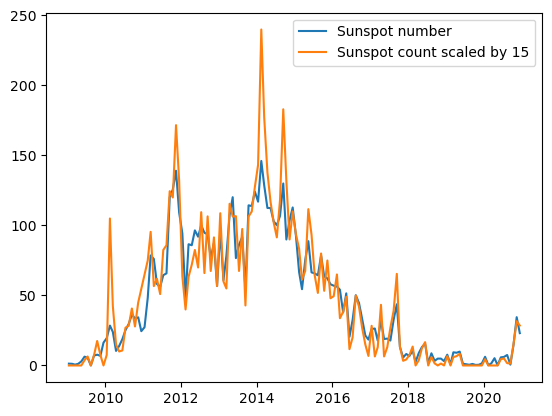

In [10]:
scale = 15

fig, ax = plt.subplots()

ax.plot_date(sunspot_numbers["Date"], sunspot_numbers["SunspotNumber"],
             '-',
             label="Sunspot number")
ax.plot_date(sunspot_counts["Date"], scale*sunspot_counts["SunspotCount"],
             "-",
             label=f"Sunspot count scaled by {scale}")
plt.legend()
plt.show()

Not bad at all!